In [1]:

#importing the required libraries


# pandas is used to work with a dataframe
import pandas as pd

# numpy is used for all numerical operations
import numpy as np

# data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#tools for preprocessing and modelling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Linear Regression model
from sklearn.linear_model import LinearRegression

# Regression evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:

#loading the dataset


df = pd.read_csv('Life Expectancy Data.csv')

#displaying the first five rows for quick info
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


Lets understand our dataset first

In [3]:


#number of rows and columns in our dataset
print("Dataset shape:", df.shape)

# Display all column names
print("\nColumn names:")
print(df.columns.tolist())


print("\nDataset information:")
df.info()

Dataset shape: (2938, 22)

Column names:
['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    29

In [4]:

#removing unnecessary spaces before and after column names
df.columns = df.columns.str.strip()

# Display cleaned column names
print(df.columns.tolist())

['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [5]:
#checking duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [6]:
#Missing value checks


# Count missing values in every column
missing_values = df.isnull().sum()

#lets see the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

#combining results into a single table
missing_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# columns that contain missing values
missing_table = missing_table[missing_table['Missing Values'] > 0]

# Sorting the columns from highest to lowest missing values
missing_table = missing_table.sort_values(by='Missing Values',ascending=False)

missing_table

,Missing Values,Percentage (%)
Population,652,22.191967
Hepatitis B,553,18.822328
GDP,448,15.248468
Total expenditure,226,7.692308
Alcohol,194,6.603131
Income composition of resources,167,5.684139
Schooling,163,5.547992
thinness 5-9 years,34,1.157250
thinness 1-19 years,34,1.157250
BMI,34,1.157250


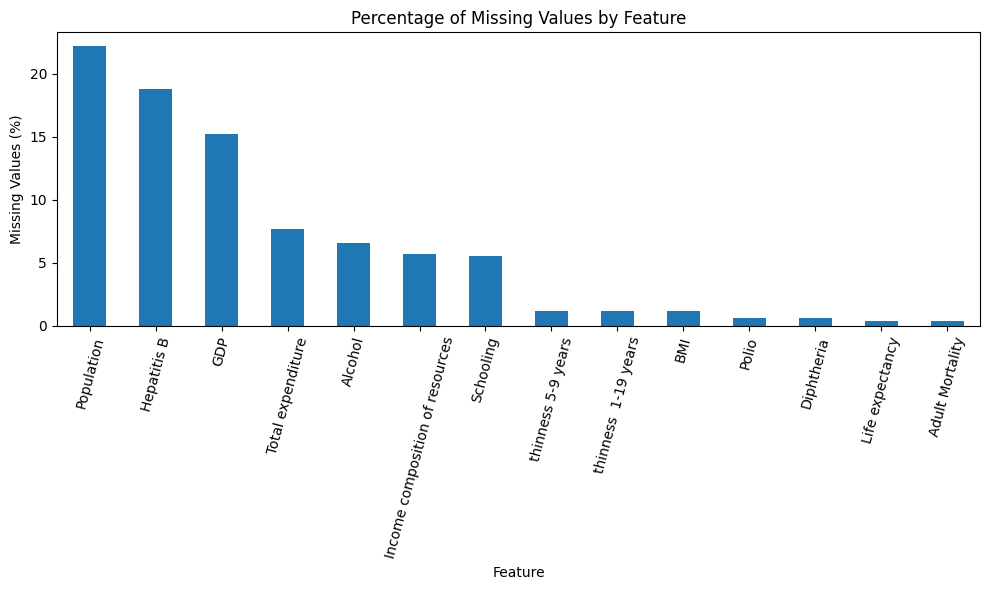

In [7]:
#lets visualize missing values


plt.figure(figsize=(10, 6))

missing_table['Percentage (%)'].plot(kind='bar')

plt.title('Percentage of Missing Values by Feature')
plt.xlabel('Feature')
plt.ylabel('Missing Values (%)')

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [8]:
#Lets analyse the Target Variable



#descriptive statistics for life expectancy
print(df['Life expectancy'].describe())

#missing target values
print(
    "\nMissing Life expectancy values:",
    df['Life expectancy'].isnull().sum()
)

count    2928.000000
mean       69.224932
std         9.523867
min        36.300000
25%        63.100000
50%        72.100000
75%        75.700000
max        89.000000
Name: Life expectancy, dtype: float64

Missing Life expectancy values: 10


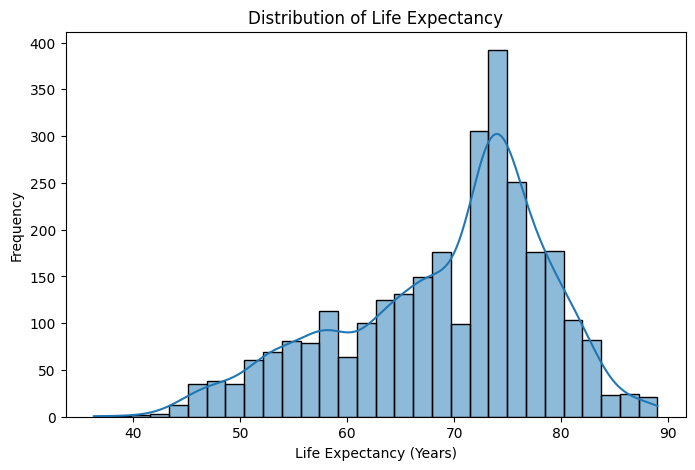

In [9]:
#Target value distribution


plt.figure(figsize=(8, 5))

sns.histplot(df['Life expectancy'],bins=30, kde=True)

plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Frequency')

plt.show()

In [10]:
#Lets compare life expectancy by development status

status_summary = df.groupby('Status')['Life expectancy'].agg(['count', 'mean', 'median', 'std'])

print(status_summary)

            count       mean  median       std
Status                                        
Developed     512  79.197852   79.25  3.930942
Developing   2416  67.111465   69.00  9.006092


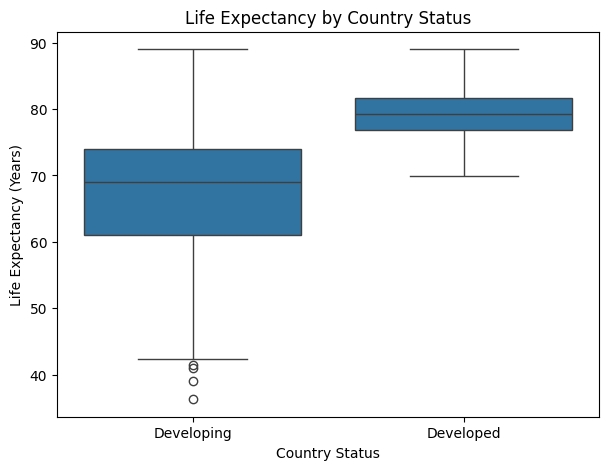

In [11]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df,x='Status',y='Life expectancy')

plt.title('Life Expectancy by Country Status')
plt.xlabel('Country Status')
plt.ylabel('Life Expectancy (Years)')

plt.show()

Exploratory Data Analysis

In [12]:
#Lets start with correlation analysis

#numerical columns
numerical_df = df.select_dtypes(include='number')

#correlation matrix
correlation_matrix = numerical_df.corr()

#correlations with life expectancy (targer variable)
life_expectancy_corr = (correlation_matrix['Life expectancy'].sort_values(ascending=False))

print(life_expectancy_corr)

Life expectancy                    1.000000
Schooling                          0.751975
Income composition of resources    0.724776
BMI                                0.567694
Diphtheria                         0.479495
Polio                              0.465556
GDP                                0.461455
Alcohol                            0.404877
percentage expenditure             0.381864
Hepatitis B                        0.256762
Total expenditure                  0.218086
Year                               0.170033
Population                        -0.021538
Measles                           -0.157586
infant deaths                     -0.196557
under-five deaths                 -0.222529
thinness 5-9 years                -0.471584
thinness  1-19 years              -0.477183
HIV/AIDS                          -0.556556
Adult Mortality                   -0.696359
Name: Life expectancy, dtype: float64


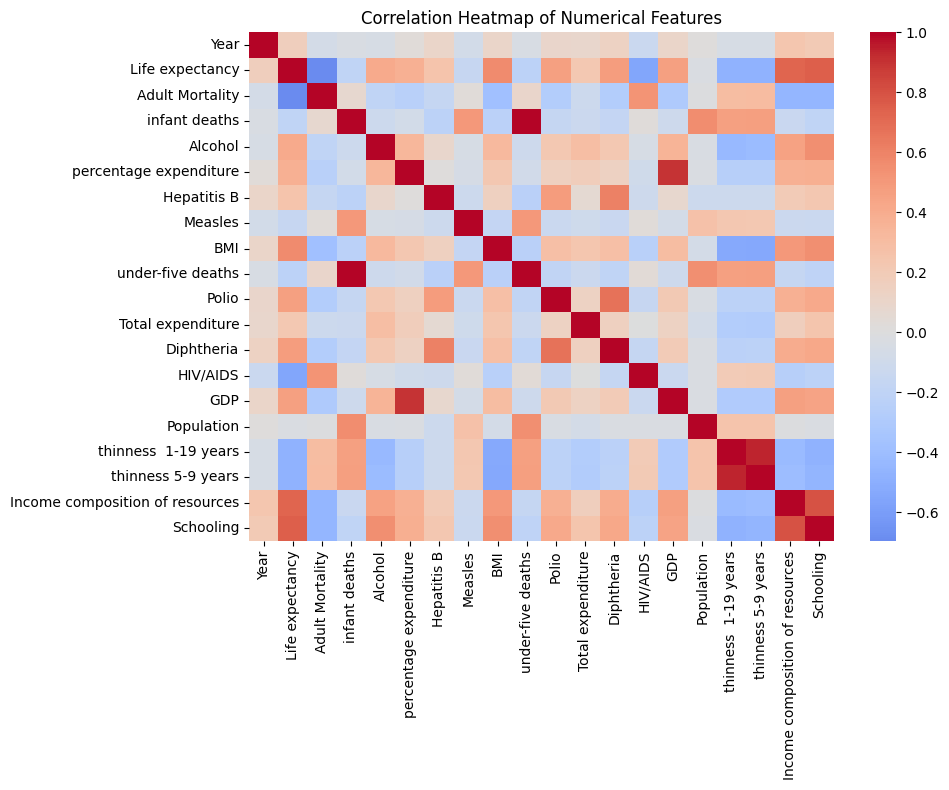

In [26]:
#Lets visualize a correlation heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix,cmap='coolwarm',center=0)

plt.title('Correlation Heatmap of Numerical Features')

plt.tight_layout()
plt.show()

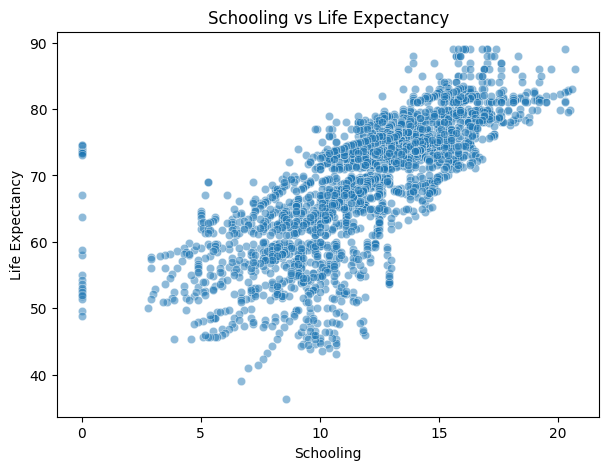

In [14]:

#relation between schooling and life expectancy

plt.figure(figsize=(7, 5))

sns.scatterplot(data=df,x='Schooling',y='Life expectancy',alpha=0.5)

plt.title('Schooling vs Life Expectancy')
plt.xlabel('Schooling')
plt.ylabel('Life Expectancy')

plt.show()

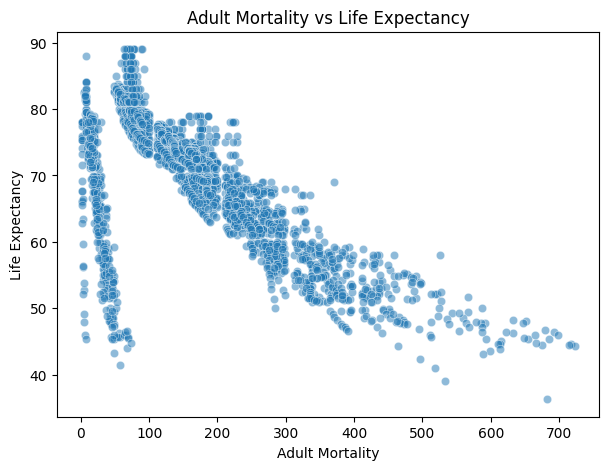

In [15]:

#relation between adult mortality vs life expectancy

plt.figure(figsize=(7, 5))

sns.scatterplot(data=df,x='Adult Mortality',y='Life expectancy',alpha=0.5)

plt.title('Adult Mortality vs Life Expectancy')
plt.xlabel('Adult Mortality')
plt.ylabel('Life Expectancy')

plt.show()

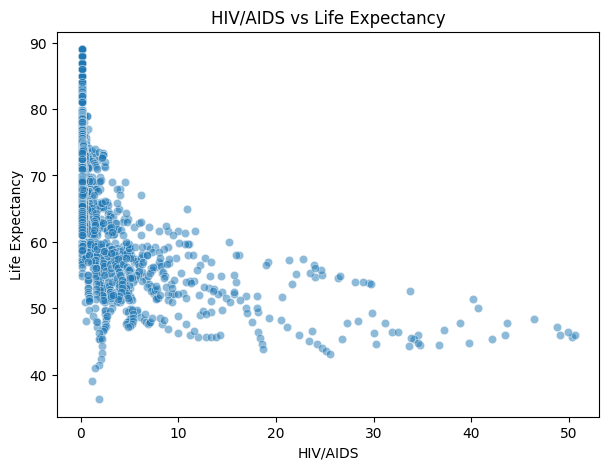

In [16]:

#HIV/AIDS vs life expectancy

plt.figure(figsize=(7, 5))

sns.scatterplot(data=df,x='HIV/AIDS',y='Life expectancy',alpha=0.5)

plt.title('HIV/AIDS vs Life Expectancy')
plt.xlabel('HIV/AIDS')
plt.ylabel('Life Expectancy')

plt.show()

In [27]:
#lets remove rows where the target variable is missing
df = df.dropna(subset=['Life expectancy'])

# Reset index after removing rows
df = df.reset_index(drop=True)


In [28]:
#now lets seperate our independent features and target variables
# X contains the predictor variables.
# Country is removed from the baseline model
X = df.drop(
    columns=['Life expectancy', 'Country'])

# y contains the target variable
y = df['Life expectancy']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2928, 20)
y shape: (2928,)


In [29]:
#lets see our feature types
#numerical columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

#categorical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Year', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']

Categorical features:
['Status']


In [30]:
# Train-test split



X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2342
Testing samples: 586


In [31]:
#Numerical preprocessing by median

numerical_transformer = Pipeline(steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        )
])

In [32]:
#categorical preprocessing using onehot encoding
categorical_transformer = Pipeline(steps=[('imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'onehot',
            OneHotEncoder(drop='first',handle_unknown='ignore'))])

In [33]:
#lets make a combned preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            'numerical',
            numerical_transformer,
            numerical_features),
        (
            'categorical',
            categorical_transformer,
            categorical_features)])

In [34]:
# Linear Regression model
#using a pipeline for preprocessing and model training
linear_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'regressor',
            LinearRegression()
        )])

In [35]:
print(X_train.shape)
print(X_train.dtypes)
print("\nMissing values:")
print(X_train.isnull().sum())

(2342, 20)
Year                                 int64
Status                              object
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
dtype: object

Missing values:
Year                                 0
Status                               0
Adult Mortality     

In [36]:
#Model training
linear_model.fit(X_train,y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [37]:
# Predictions with the baseline model
y_pred = linear_model.predict(X_test)

# Displaying the first 10 predictions
comparison = pd.DataFrame({'Actual Life Expectancy': y_test.values,
    'Predicted Life Expectancy': y_pred})

comparison.head(10)

,Actual Life Expectancy,Predicted Life Expectancy
0,56.5,54.843768
1,73.0,68.981734
2,82.5,80.078348
3,75.6,76.680983
4,53.0,58.364586
5,65.2,64.258027
6,72.4,72.823400
7,74.1,75.439366
8,77.0,76.130930
9,67.8,72.596575


In [38]:
#Lets evaluate our model

mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))

r2 = r2_score(y_test,y_pred)

print("Linear Regression Results\n")

print(f"MAE:  {mae:.2f} years")
print(f"RMSE: {rmse:.2f} years")
print(f"R²:   {r2:.4f}")

Linear Regression Results

MAE:  2.93 years
RMSE: 3.95 years
R²:   0.8195


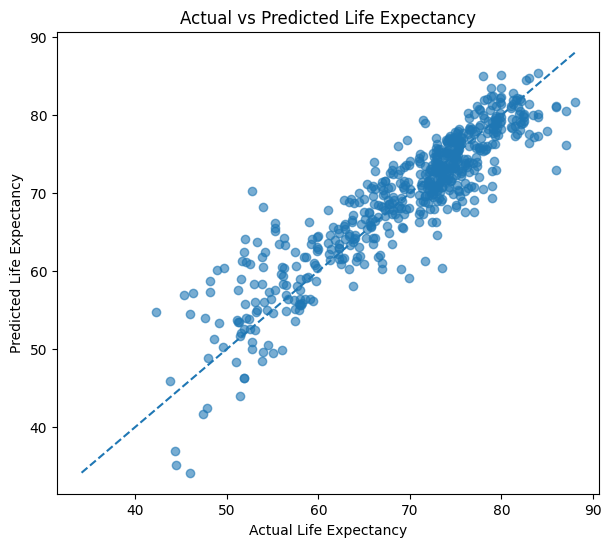

In [39]:
#Lets visualize the results as well
plt.figure(figsize=(7, 6))

plt.scatter(y_test,y_pred,alpha=0.6)

#reference line for the perfect prediction
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot([minimum, maximum],[minimum, maximum],linestyle='--')

plt.title('Actual vs Predicted Life Expectancy')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')

plt.show()

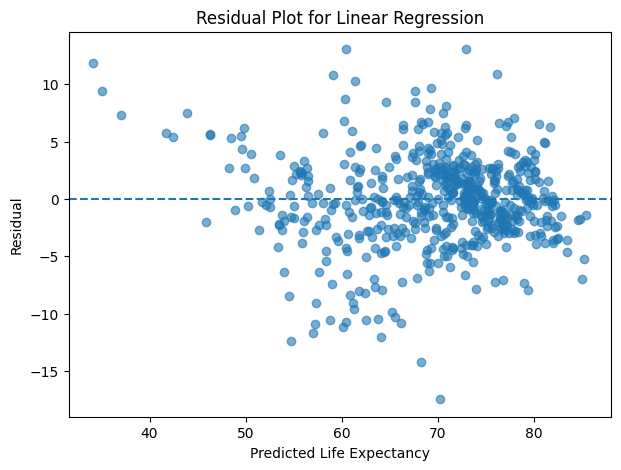

In [40]:
#residual analysis
# Residual = actual value - predicted value
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(y_pred,residuals,alpha=0.6)

plt.axhline(y=0,linestyle='--')

plt.title('Residual Plot for Linear Regression')
plt.xlabel('Predicted Life Expectancy')
plt.ylabel('Residual')

plt.show()